**Planned workflow for point 4**

1. **Don't fit KDE** - fit raw data directly using Maximum Likelihood Estimation (MLE) via `scipy.stats` distributions' `.fit()` method

2. **Correct workflow:**
   - Histogram for visualization only
   - Fit raw increment data: `scipy.stats.norm.fit(data)` returns (μ, σ)
   - For non-Gaussian: try `scipy.stats.levy_stable`, `scipy.stats.t` (Student-t), or custom Tsallis/stretched exponential

3. **Goodness of fit indicators:**
   - **Kolmogorov-Smirnov test**: `scipy.stats.kstest(data, fitted_dist.cdf)`
   - **Anderson-Darling**: `scipy.stats.anderson(data, dist='norm')`
   - **Q-Q plots**: `scipy.stats.probplot(data, dist=fitted_dist)`
   - NOT MSE (inappropriate for probability distributions)

4. **Key functions:**
   - `scipy.stats.<dist>.fit()` - MLE fitting
   - `scipy.stats.kstest()` - goodness of fit
   - `seaborn.histplot(kde=True)` - visualization
   - `scipy.optimize.curve_fit()` - if custom PDF needed

In [115]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import seaborn as sns
import numpy as np
rng=np.random.default_rng(seed=1)

In [116]:
print(sns.__version__)
import matplotlib.colors as mcolors
print(list(mcolors.CSS4_COLORS.keys()))

0.13.2
['aliceblue', 'antiquewhite', 'aqua', 'aquamarine', 'azure', 'beige', 'bisque', 'black', 'blanchedalmond', 'blue', 'blueviolet', 'brown', 'burlywood', 'cadetblue', 'chartreuse', 'chocolate', 'coral', 'cornflowerblue', 'cornsilk', 'crimson', 'cyan', 'darkblue', 'darkcyan', 'darkgoldenrod', 'darkgray', 'darkgreen', 'darkgrey', 'darkkhaki', 'darkmagenta', 'darkolivegreen', 'darkorange', 'darkorchid', 'darkred', 'darksalmon', 'darkseagreen', 'darkslateblue', 'darkslategray', 'darkslategrey', 'darkturquoise', 'darkviolet', 'deeppink', 'deepskyblue', 'dimgray', 'dimgrey', 'dodgerblue', 'firebrick', 'floralwhite', 'forestgreen', 'fuchsia', 'gainsboro', 'ghostwhite', 'gold', 'goldenrod', 'gray', 'green', 'greenyellow', 'grey', 'honeydew', 'hotpink', 'indianred', 'indigo', 'ivory', 'khaki', 'lavender', 'lavenderblush', 'lawngreen', 'lemonchiffon', 'lightblue', 'lightcoral', 'lightcyan', 'lightgoldenrodyellow', 'lightgray', 'lightgreen', 'lightgrey', 'lightpink', 'lightsalmon', 'lightseag

In [137]:
def standardize_increments(increments:np.ndarray):
    increments_standardized=(increments-np.mean(increments))/np.std(increments)
    return increments_standardized

def histo_kde(increments:np.ndarray, h_ax, bin_edges, xlabel="Standardized increments", hist_color='lightblue', line_color='blue'):
    # assuming increments array (at a fixed scale s),
    # and a single "heart" sample (can generalize by putting everything in a sigle array?)
    # NB requires eisting ax
    h_ax.set_xlabel(xlabel)
    h_ax.set_ylabel("Frequence")
    h_ax.hist(increments, bins=bin_edges, density=True, color=hist_color, label='Data')
    sns.kdeplot(increments, color=line_color, linewidth=2, label="KDE-estimated PDF", ax=h_ax)
    h_ax.legend()
    plt.savefig('./point4_histo.png', dpi=300, bbox_inches='tight')

In [133]:
def gaussian_fit(increments:np.ndarray, g_ax, bin_edges, scatter_color='lightblue', scatter_marker='o', line_color='r'):
    # increments should be standardized here
    # NB requires eisting ax
    g_ax.set_xlabel("Standardized increments")
    g_ax.set_ylabel("Frequence")
    
    heights, edges = np.histogram(increments, bins=bin_edges, density=True)
    centers = (edges[:-1] + edges[1:]) / 2
    g_ax.scatter(centers, heights, color=scatter_color, marker=scatter_marker, label='Data')
    
    mu, sigma = sp.stats.norm.fit(increments)
    lin = np.linspace(increments.min(), increments.max(), 1000)
    g_ax.plot(lin, sp.stats.norm.pdf(x=lin, loc=mu, scale=sigma), '-', color=line_color, label='Gaussian fit')
    g_ax.set_yscale('log')
    g_ax.set_ylim(bottom=1e-4)
    g_ax.legend()
    plt.savefig('./point4_gaussianfit.png', dpi=300, bbox_inches='tight')
    print(mu, sigma)

[ 0.66770131  0.09423774  0.36301048 -0.64295925  1.29572048  0.49086635
 -0.23762401 -0.16083571  1.28042805 -0.62715447]
9.947598300641403e-17 0.9999999999999999


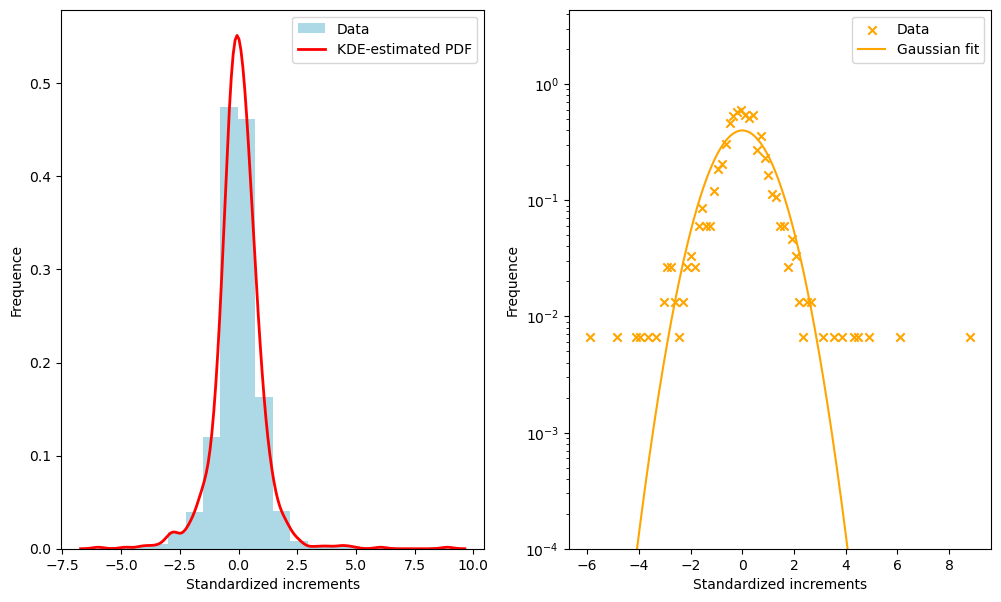

In [138]:
# ---> comparison:
#incs=rng.normal(loc=1.2, scale=0.3, size=1000)
t_dist = sp.stats.t(df=3, loc=1.2, scale=0.3)  
incs = t_dist.rvs(size=1000)
#print(incs[:10], bes)
cincs=standardize_increments(incs)
print(cincs[:10])
bes=np.linspace(cincs.min(), cincs.max(), 21)
bes2=np.linspace(cincs.min(), cincs.max(), 100)

fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12,7))
histo_kde(increments=cincs, h_ax=ax1, bin_edges=bes, hist_color='lightblue', line_color='red')
gaussian_fit(increments=cincs, g_ax=ax2, bin_edges=bes2, scatter_color='orange', scatter_marker='x', line_color='orange')